In [4]:
import pandas   as pd

df = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(df.head())


   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

With the utility functions defined above, we can now refactor the initial data loading and preparation steps. First, we'll load the data and perform initial preprocessing to get `X_raw` and `y`. Then, we'll apply feature engineering (one-hot encoding and scaling) to transform `X_raw` into `X_processed`.

## Exploratory Data Analysis (EDA)

Let's get an overview of the DataFrame, including its structure (data types, non-null counts) and descriptive statistics for numerical columns.

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [ ]:
from altair.vegalite.v6 import display
display(df.describe())

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Now, let's check for any missing values in the dataset.

In [7]:
display(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Distribution of Numerical Features

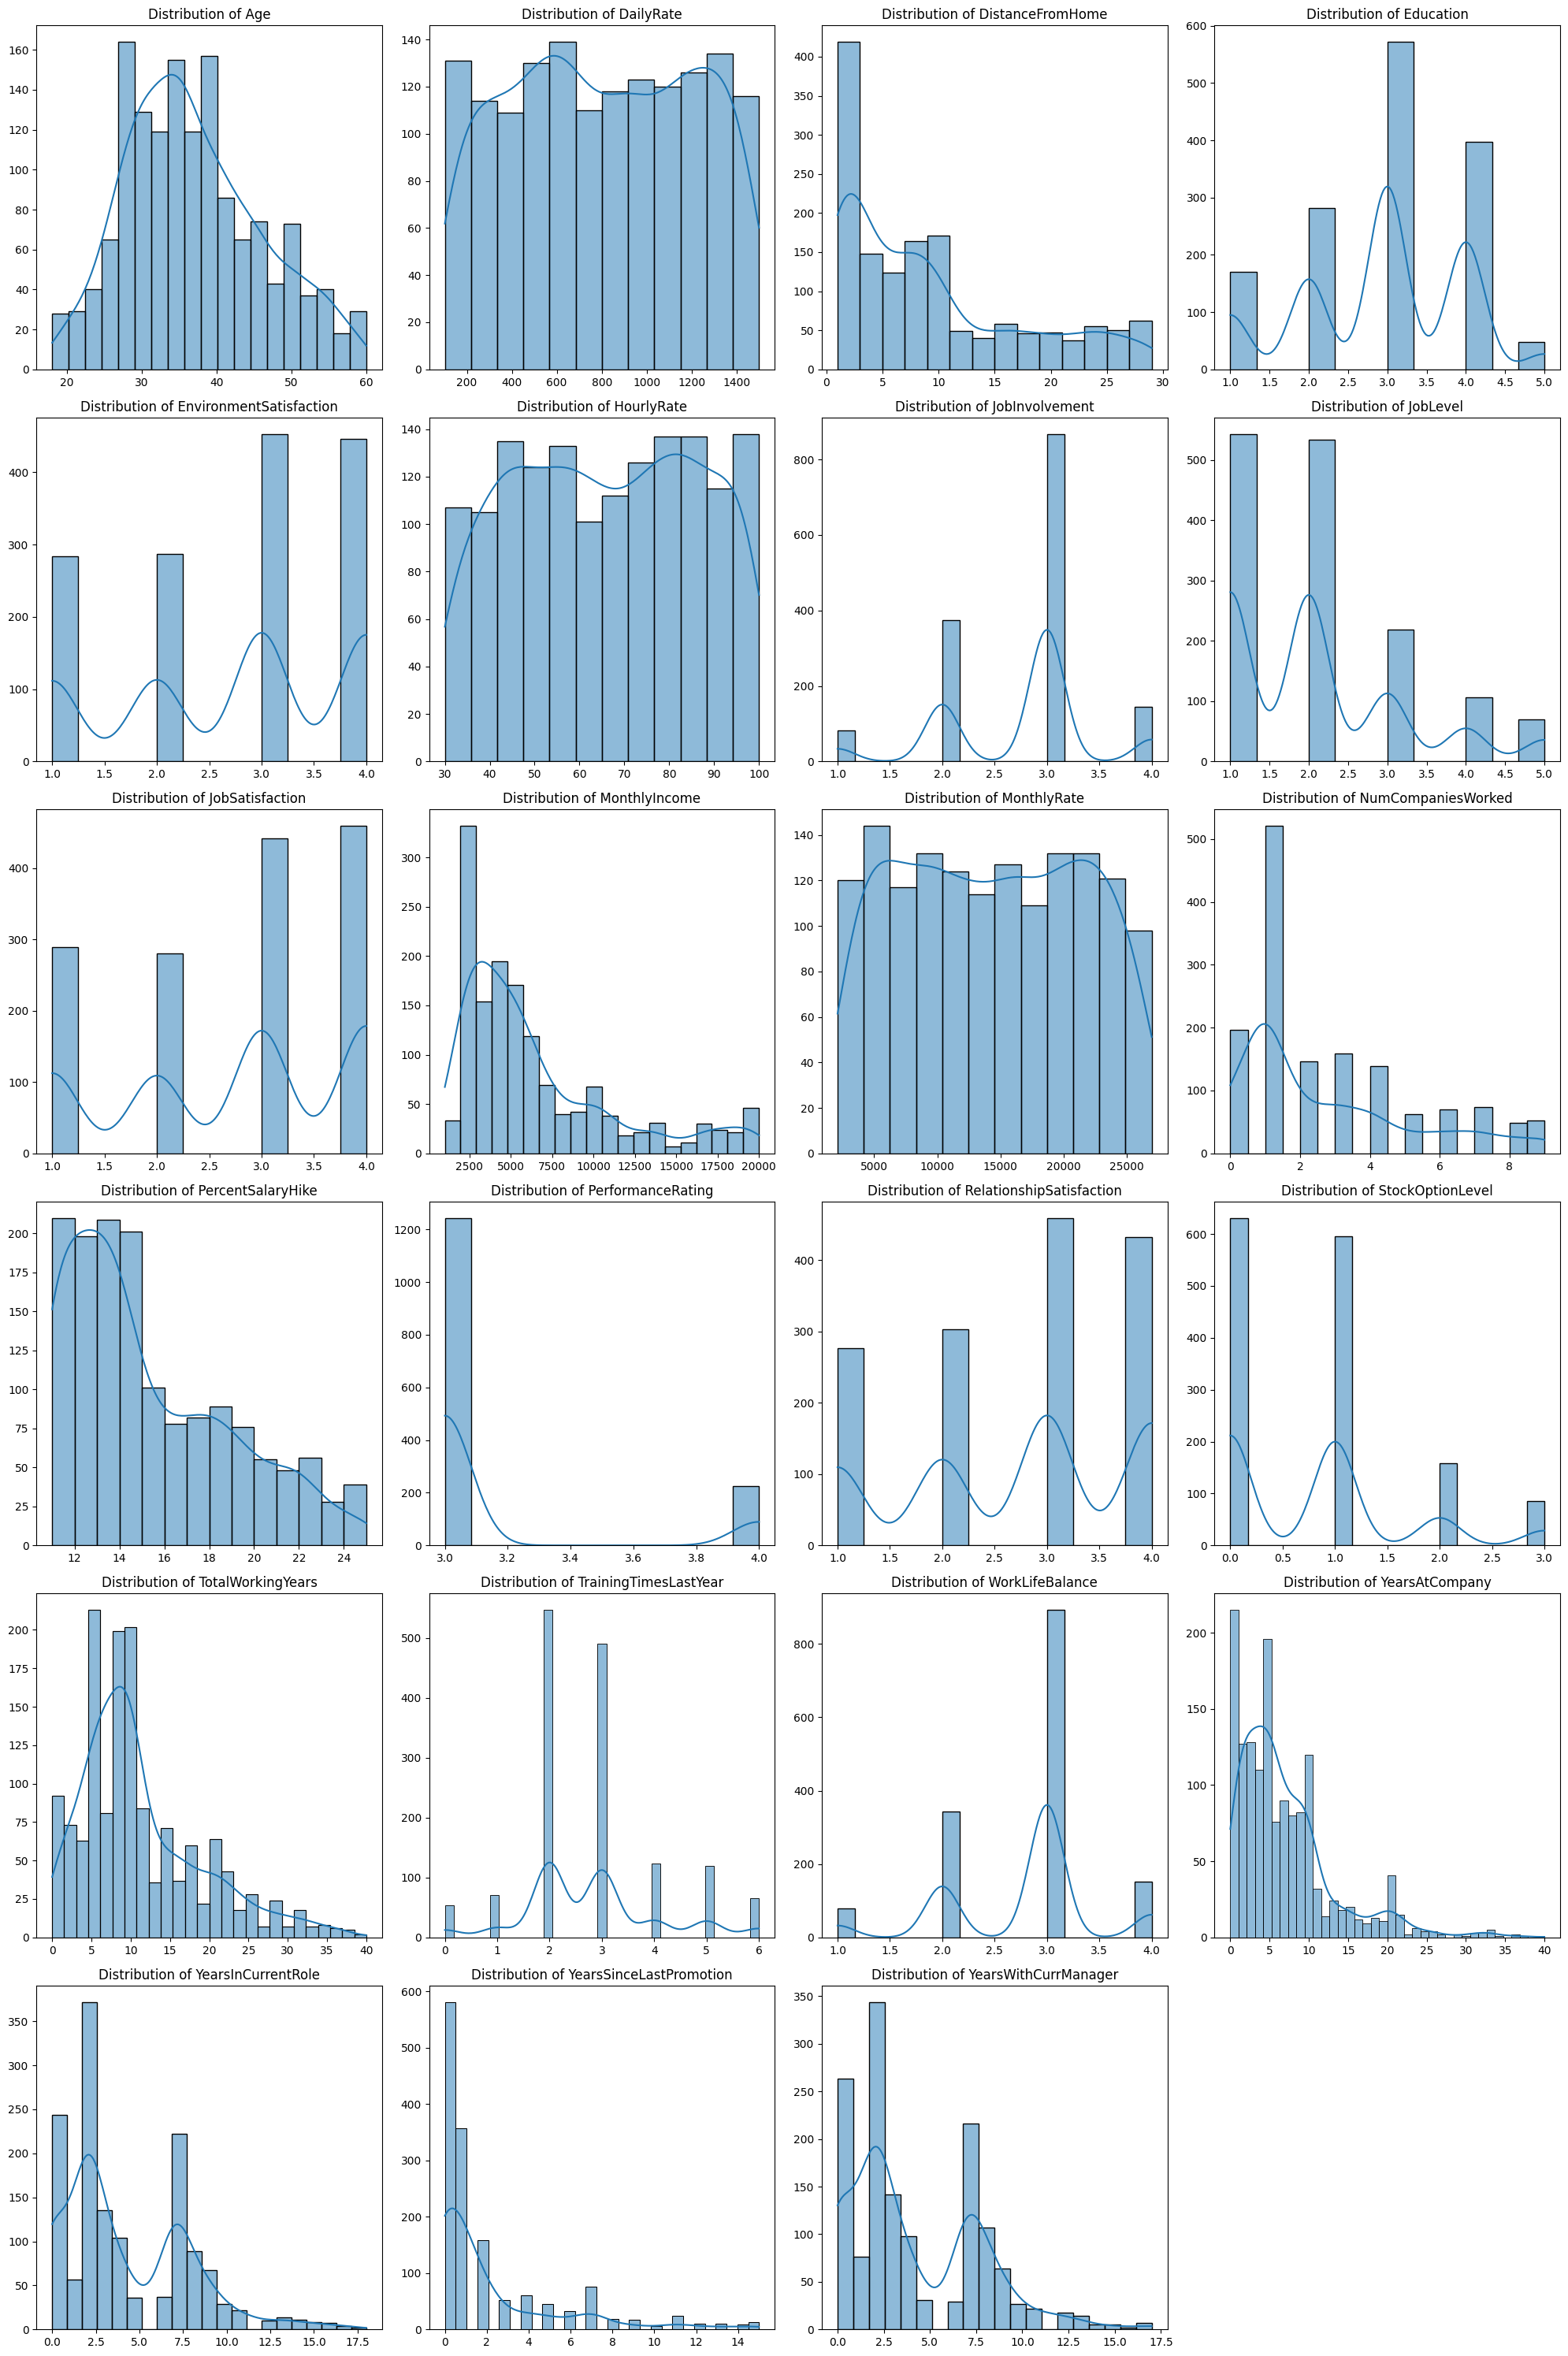

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns for plotting, excluding 'EmployeeCount' and 'StandardHours'
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
exclude_cols = ['EmployeeCount', 'StandardHours', 'EmployeeNumber'] # EmployeeNumber is an ID, not a feature
numerical_cols = [col for col in numerical_cols if col not in exclude_cols]

# Set up the matplotlib figure and axes
fig, axes = plt.subplots(nrows=len(numerical_cols)//4 + 1, ncols=4, figsize=(20, 5 * (len(numerical_cols)//4 + 1)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Distribution of Categorical Features

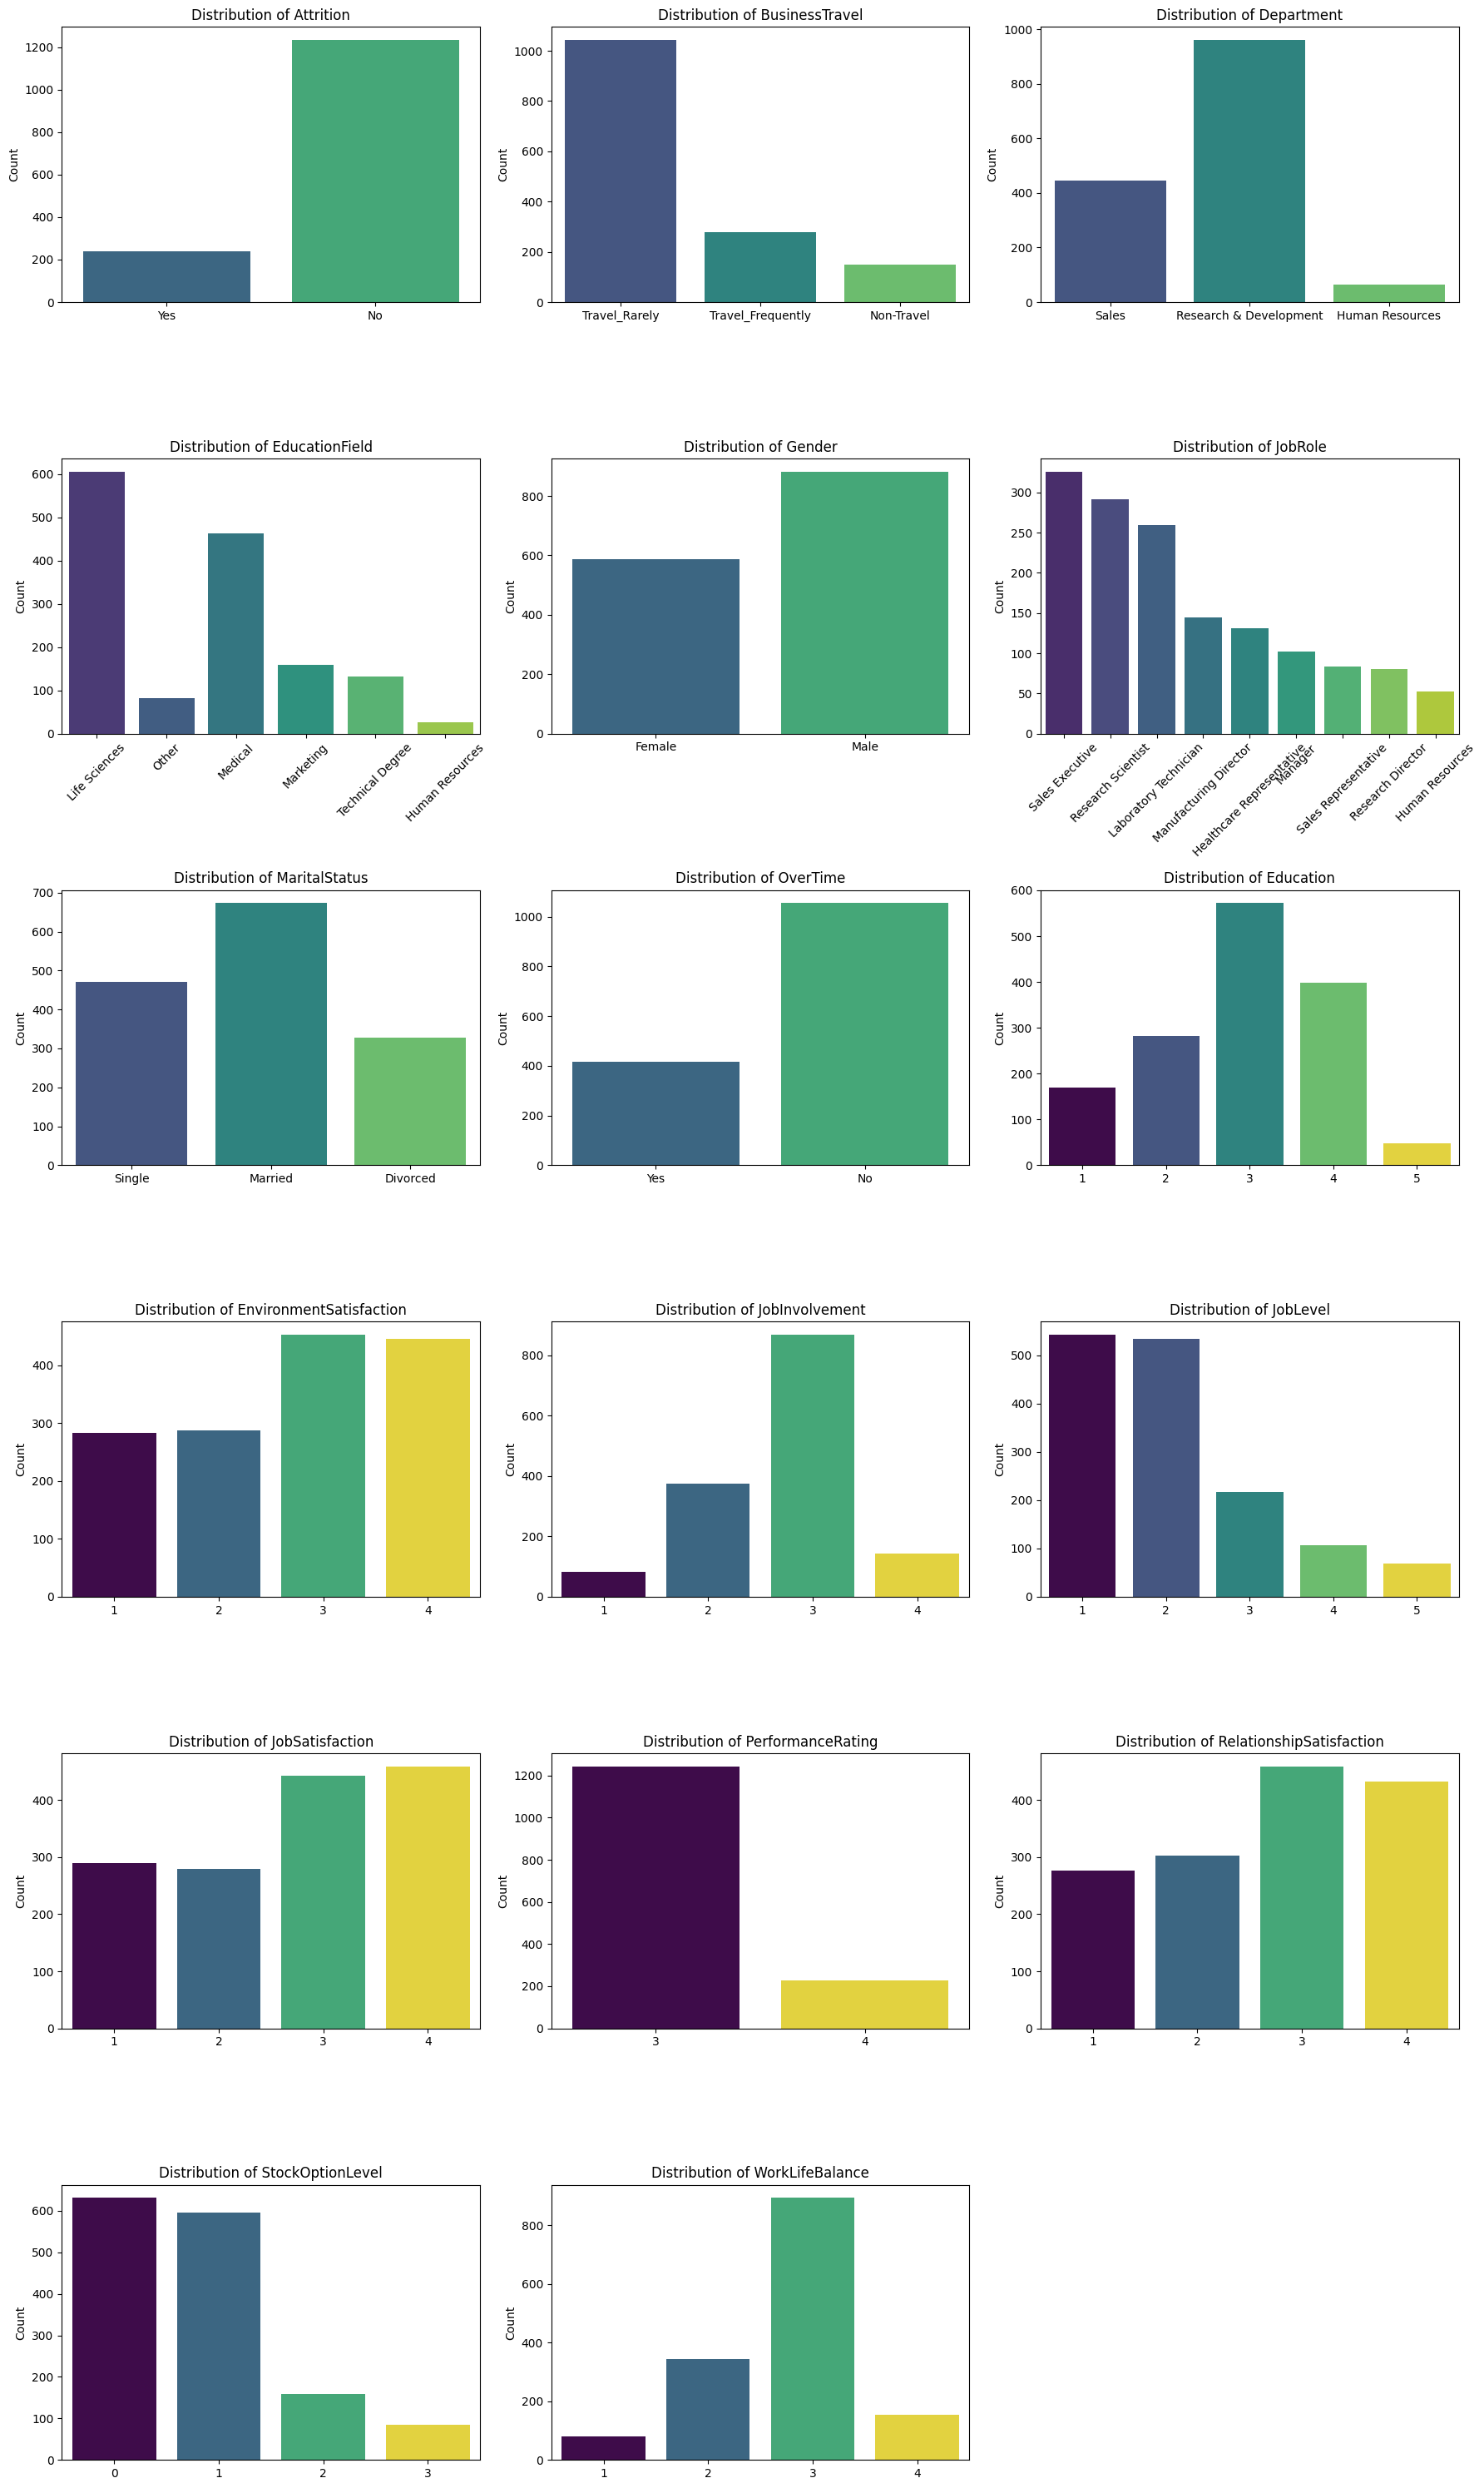

In [7]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Also consider numerical columns that are likely categorical (e.g., ratings, levels)
ordinal_cols = [
    'Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel',
    'JobSatisfaction', 'PerformanceRating', 'RelationshipSatisfaction',
    'StockOptionLevel', 'WorkLifeBalance'
]

categorical_cols.extend(ordinal_cols)

# Exclude columns that were identified as constants or identifiers
exclude_cols = ['EmployeeCount', 'StandardHours', 'EmployeeNumber', 'Over18'] # Over18 is likely constant based on common datasets of this type
categorical_cols = [col for col in categorical_cols if col not in exclude_cols]

# Set up the matplotlib figure and axes
num_plots = len(categorical_cols)
num_rows = (num_plots // 3) + (1 if num_plots % 3 > 0 else 0)

fig, axes = plt.subplots(nrows=num_rows, ncols=3, figsize=(18, 5 * num_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, hue=col, ax=axes[i], palette='viridis', legend=False)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count')
    # Rotate x-axis labels if there are too many categories
    if df[col].nunique() > 5:
        axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Correlation Analysis

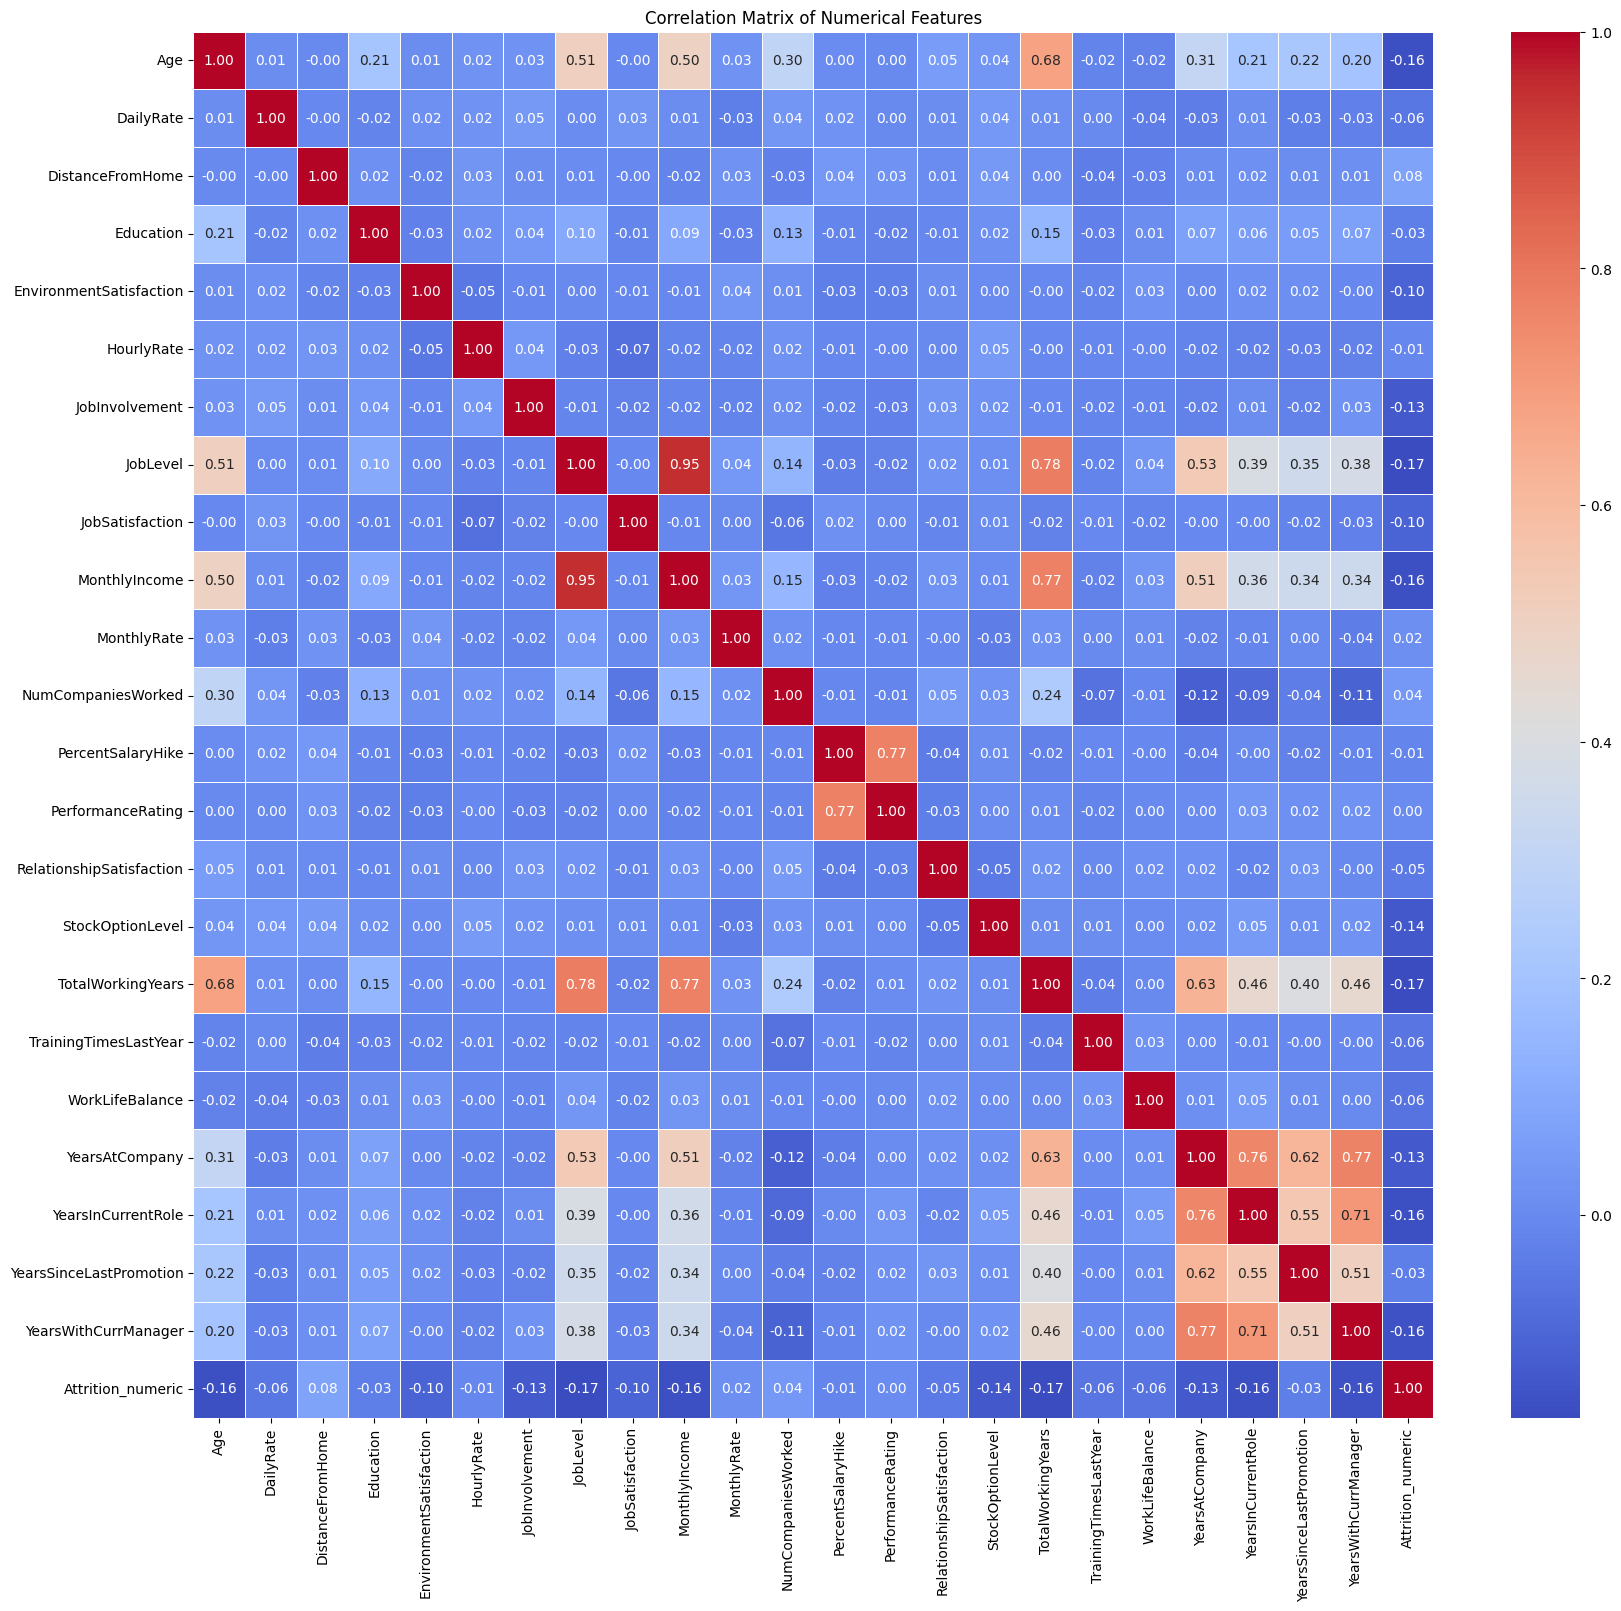

In [8]:
# Convert 'Attrition' to numerical (Yes=1, No=0) for correlation analysis
df['Attrition_numeric'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# Select numerical columns for correlation, including the new 'Attrition_numeric'
# Re-using the previously defined numerical_cols and adding 'Attrition_numeric'
correlation_cols = [col for col in numerical_cols if col != 'Attrition'] # Ensure 'Attrition' object type is not in numerical_cols
correlation_cols.append('Attrition_numeric')

# Calculate the correlation matrix
corr_matrix = df[correlation_cols].corr()

# Plot the heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Bivariate Analysis with Attrition




#### Numerical Features vs. Attrition

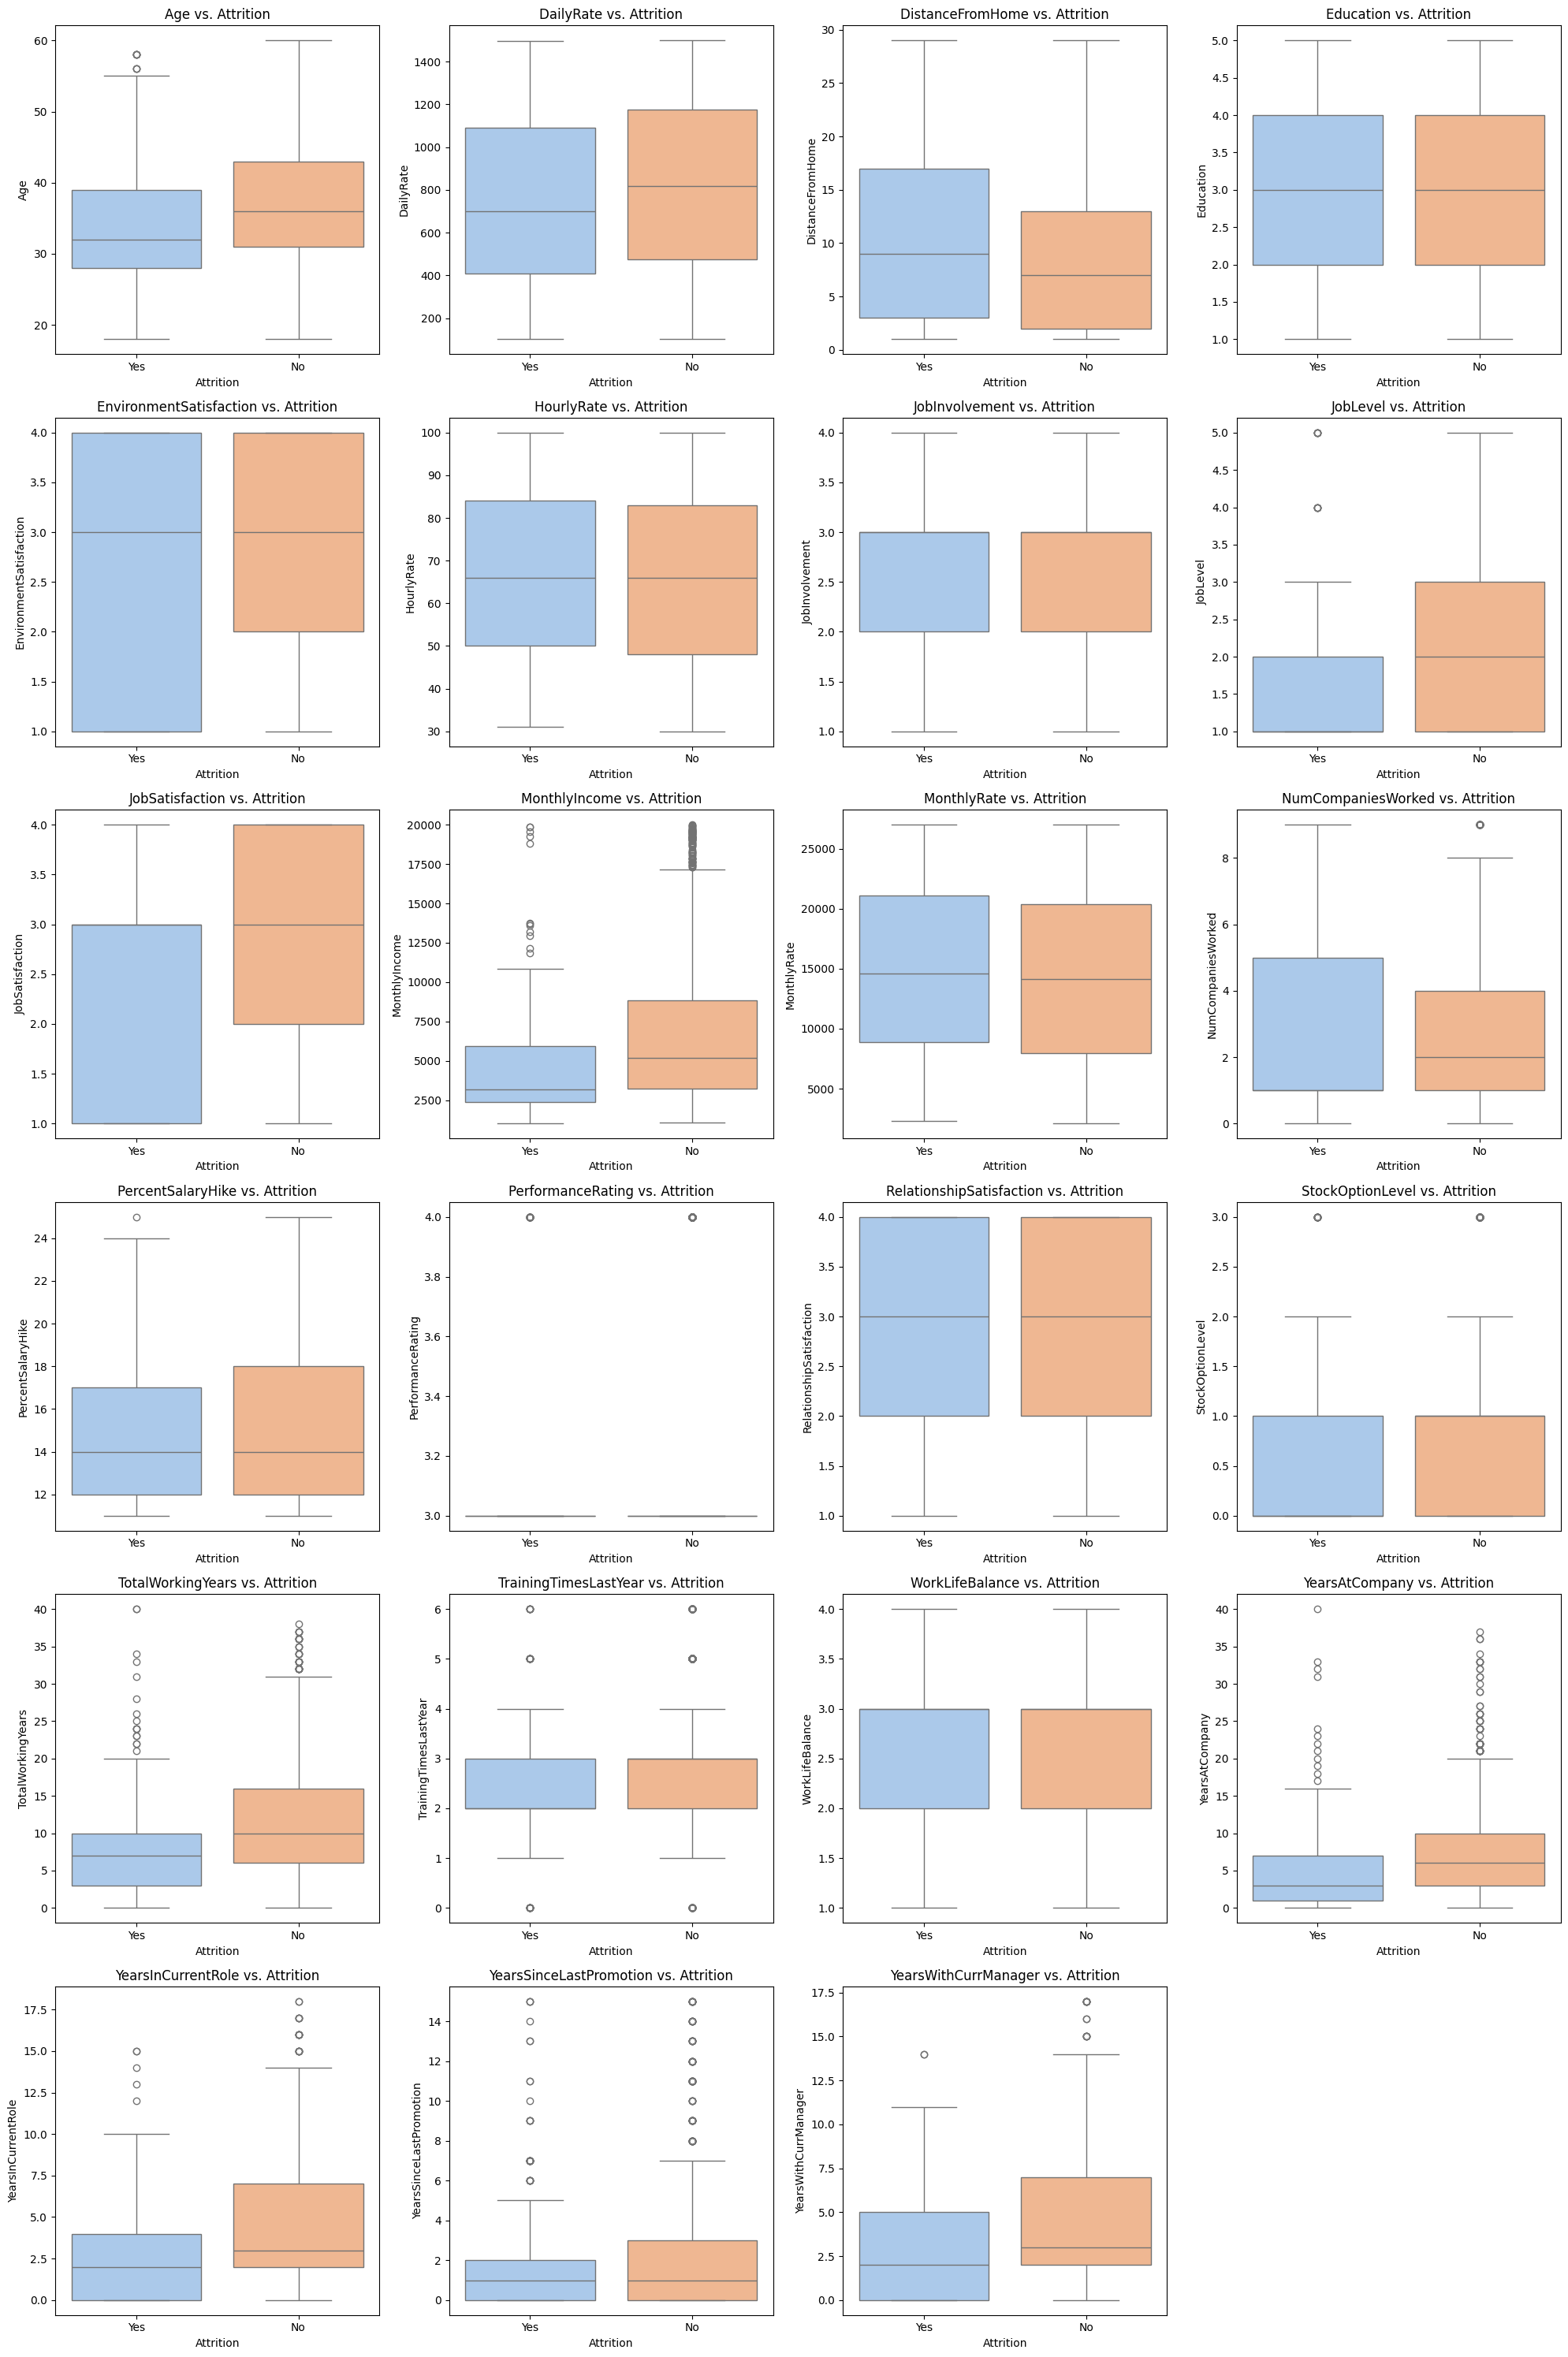

In [9]:
fig, axes = plt.subplots(nrows=len(numerical_cols)//4 + 1, ncols=4, figsize=(20, 5 * (len(numerical_cols)//4 + 1)))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    if col != 'Attrition_numeric': # Avoid plotting Attrition against itself
        sns.boxplot(x='Attrition', y=col, data=df, ax=axes[i], palette='pastel', hue='Attrition', legend=False)
        axes[i].set_title(f'{col} vs. Attrition')
        axes[i].set_xlabel('Attrition')
        axes[i].set_ylabel(col)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Categorical Features vs. Attrition

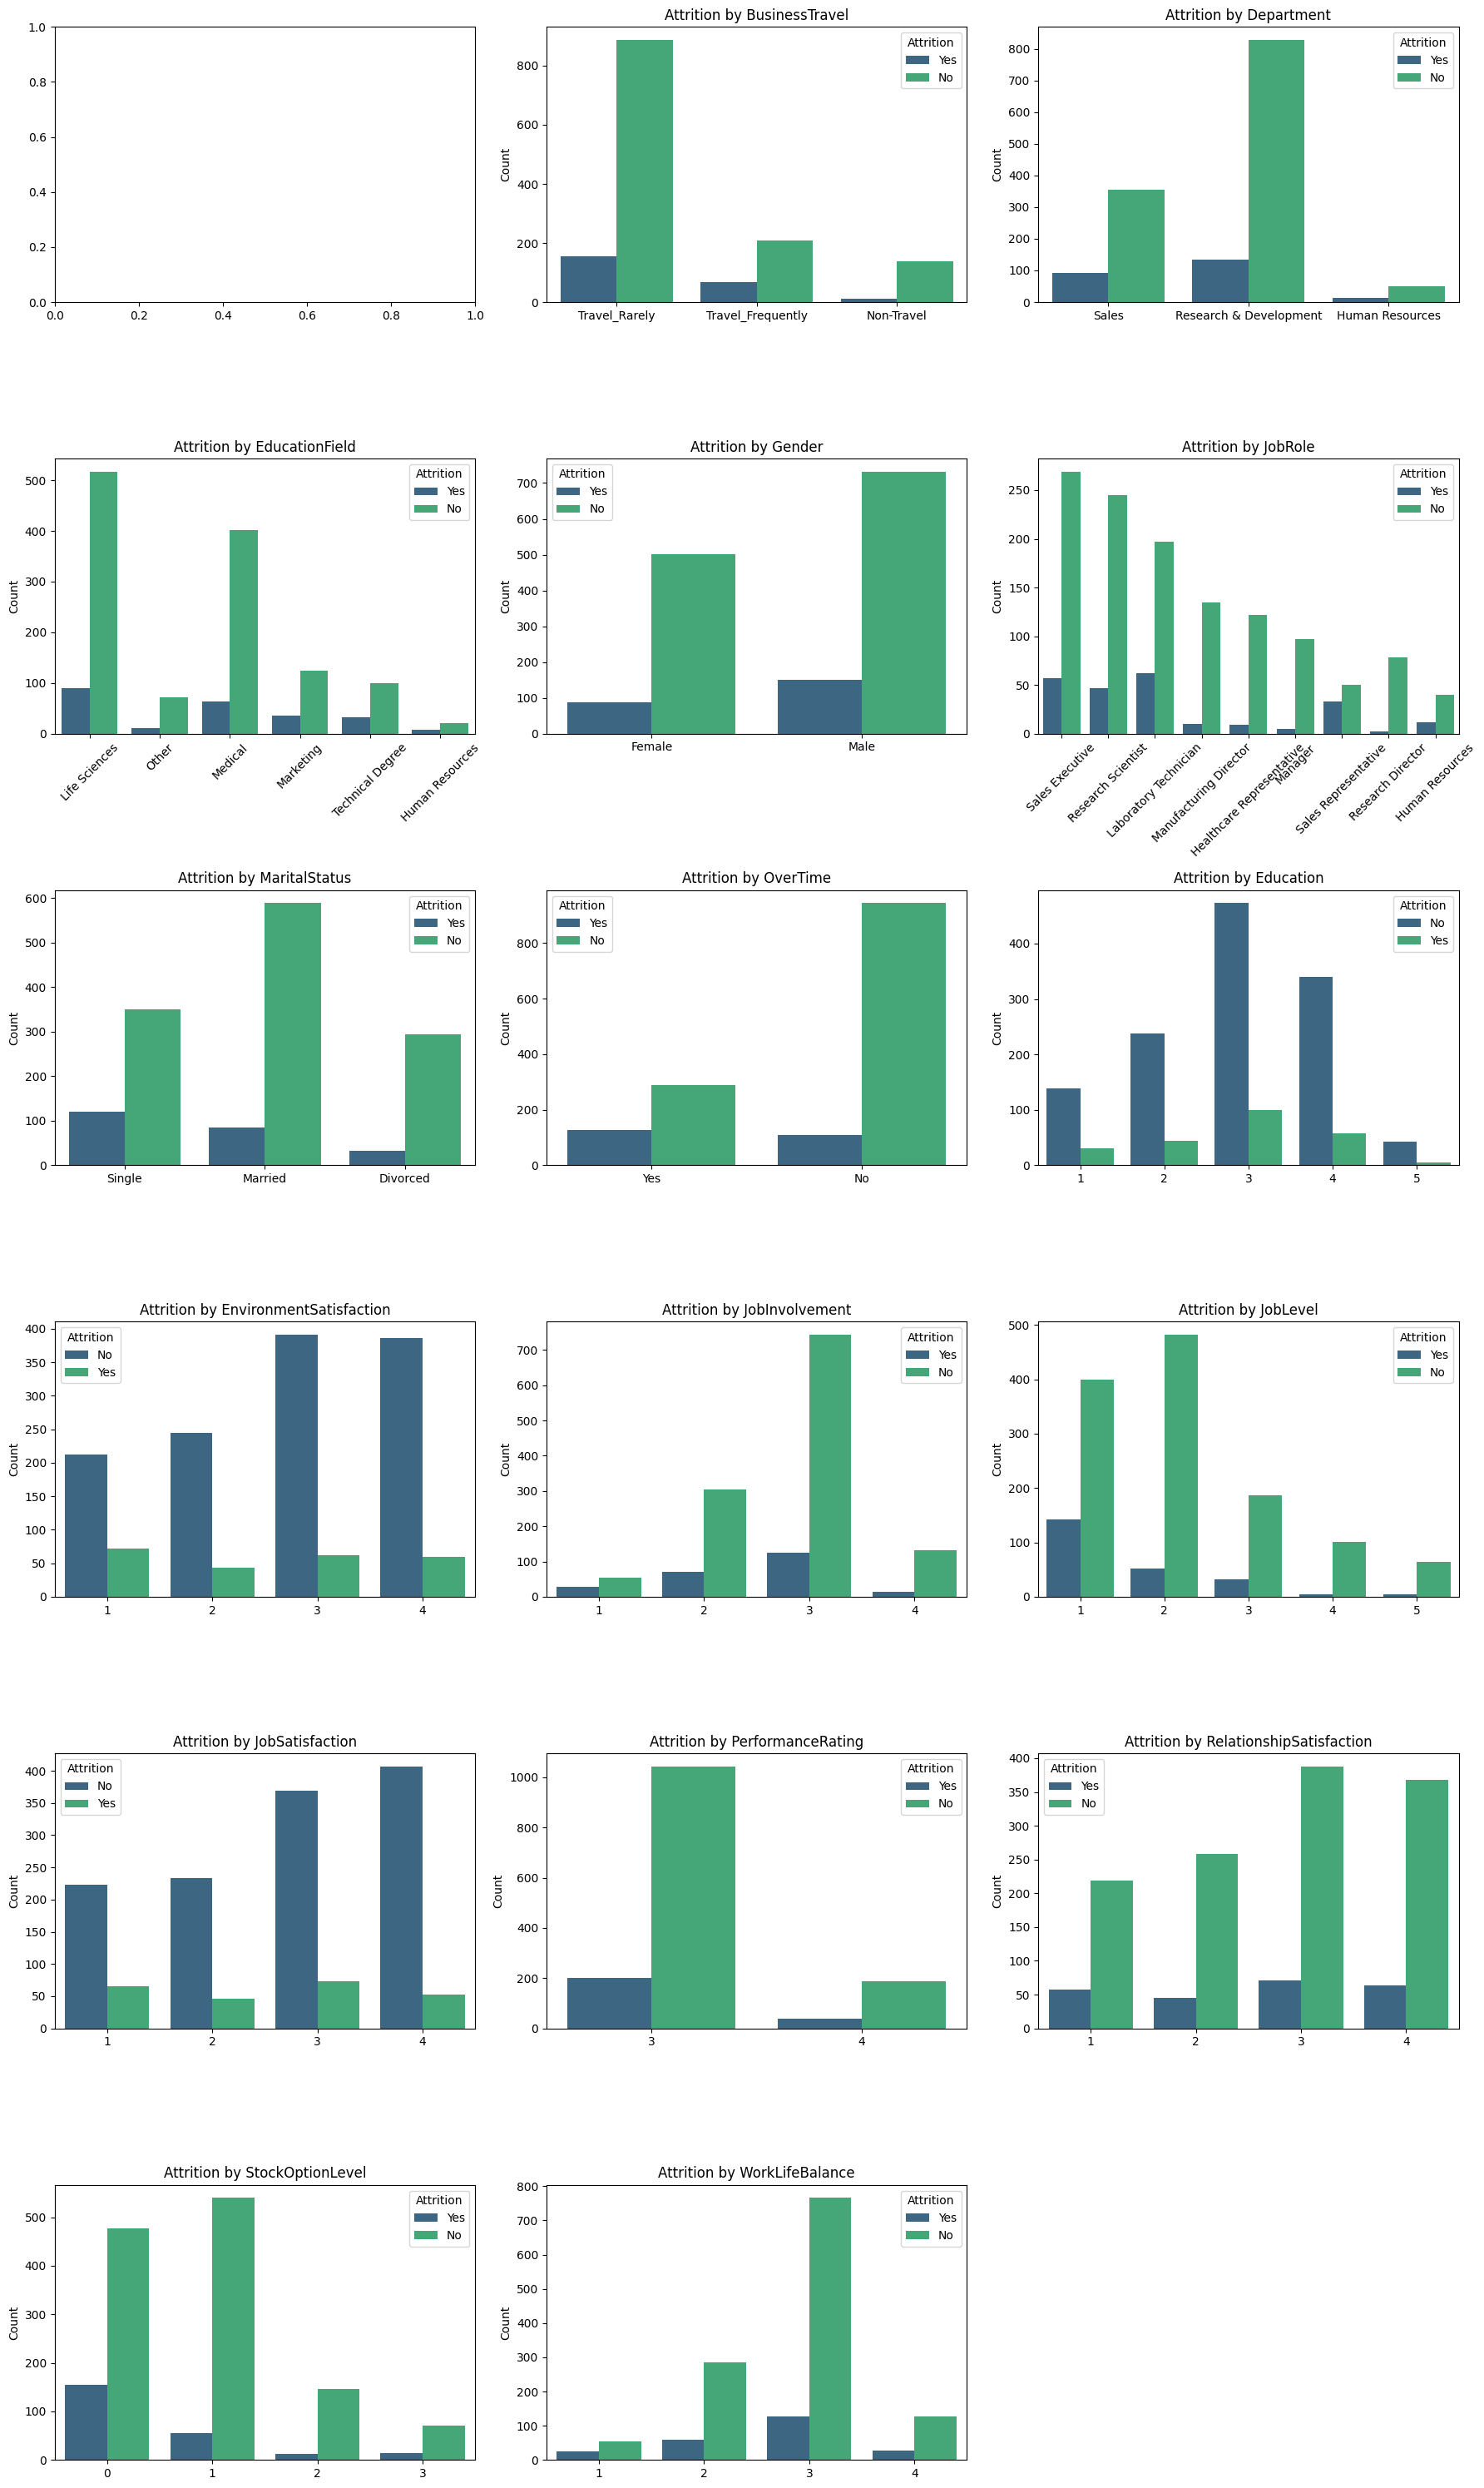

In [10]:
fig, axes = plt.subplots(nrows=len(categorical_cols)//3 + 1, ncols=3, figsize=(18, 5 * (len(categorical_cols)//3 + 1)))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if col != 'Attrition': # Avoid plotting Attrition against itself
        sns.countplot(data=df, x=col, hue='Attrition', ax=axes[i], palette='viridis')
        axes[i].set_title(f'Attrition by {col}')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Count')
        if df[col].nunique() > 5:
            axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Feature Engineering and Data Preparation

First, we will drop columns that were identified as uninformative during EDA or are redundant. This includes `EmployeeCount`, `StandardHours`, `EmployeeNumber`, `Over18`, and the original `Attrition` column (as we have `Attrition_numeric`).

In [ ]:
# Using the utility function to load and perform initial preprocessing
df_processed, X_raw, y = load_and_initial_preprocess('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Shape of DataFrame after initial preprocessing: {df_processed.shape}")
print(f"Shape of raw features (X_raw): {X_raw.shape}")
print(f"Shape of target (y): {y.shape}")

Shape of DataFrame after initial preprocessing: (1470, 31)
Shape of raw features (X_raw): (1470, 30)
Shape of target (y): (1470,)


Next, we will separate the features (X) from the target variable (y), which is `Attrition_numeric`.

In [36]:
# Using the utility function to apply feature engineering and scaling
X, scaler, categorical_cols_X, numerical_cols_X = apply_feature_engineering_and_scaling(X_raw)

print(f"Categorical columns in X: {categorical_cols_X}")
print(f"Numerical columns in X: {numerical_cols_X}")
print(f"Shape of X after One-Hot Encoding and Scaling: {X.shape}")
display(X.head())

Categorical columns in X: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Numerical columns in X: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Shape of X after One-Hot Encoding and Scaling: (1470, 44)


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,0.742527,-1.010909,-0.891688,-0.660531,1.383138,0.379672,-0.057788,1.153254,-0.108350,...,False,False,False,False,False,True,False,False,True,True
1,1.322365,-1.297775,-0.147150,-1.868426,0.254625,-0.240677,-1.026167,-0.057788,-0.660853,-0.291719,...,False,False,False,False,True,False,False,True,False,False
2,0.008343,1.414363,-0.887515,-0.891688,1.169781,1.284725,-1.026167,-0.961486,0.246200,-0.937654,...,True,False,False,False,False,False,False,False,True,True
3,-0.429664,1.461466,-0.764121,1.061787,1.169781,-0.486709,0.379672,-0.961486,0.246200,-0.763634,...,False,False,False,False,True,False,False,True,False,True
4,-1.086676,-0.524295,-0.887515,-1.868426,-1.575686,-1.274014,0.379672,-0.961486,-0.660853,-0.644858,...,True,False,False,False,False,False,False,True,False,False


Finally, we will split the dataset into training and testing sets. This allows us to train a machine learning model on one subset of the data and evaluate its performance on unseen data.

In [15]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Class distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("Class distribution in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (1176, 44)
X_test shape: (294, 44)
y_train shape: (1176,)
y_test shape: (294,)
Class distribution in y_train:
Attrition_numeric
0    0.838435
1    0.161565
Name: proportion, dtype: float64
Class distribution in y_test:
Attrition_numeric
0    0.840136
1    0.159864
Name: proportion, dtype: float64


### Handling Class Imbalance with SMOTE

In [16]:
# Install imblearn if not already installed
try:
    import imblearn
except ImportError:
    %pip install imblearn
    import imblearn

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Shape of X_train after SMOTE: {X_train_resampled.shape}")
print(f"Shape of y_train after SMOTE: {y_train_resampled.shape}")

print("\nClass distribution in y_train after SMOTE:")
print(y_train_resampled.value_counts(normalize=True))

Shape of X_train after SMOTE: (1972, 44)
Shape of y_train after SMOTE: (1972,)

Class distribution in y_train after SMOTE:
Attrition_numeric
0    0.5
1    0.5
Name: proportion, dtype: float64


## Model Training and Evaluation

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the Logistic Regression model
# Using 'liblinear' solver for better performance with L1/L2 regularization on smaller datasets
model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')
model.fit(X_train_resampled, y_train_resampled)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
print("### Logistic Regression Model Performance (class_weight='balanced') ###")
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

### Logistic Regression Model Performance (class_weight='balanced') ###

Accuracy: 0.8571428571428571

Confusion Matrix:
 [[229  18]
 [ 24  23]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92       247
           1       0.56      0.49      0.52        47

    accuracy                           0.86       294
   macro avg       0.73      0.71      0.72       294
weighted avg       0.85      0.86      0.85       294



In [42]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
lr_model = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced')

# Train and evaluate the Logistic Regression model using the utility function
lr_model, lr_metrics = train_and_evaluate_classifier(
    lr_model,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    model_name="Logistic Regression (Initial, with class_weight='balanced')"
)

# Store initial LR metrics for comparison later
model_f1_scores['Logistic Regression (Initial)'] = lr_metrics['f1_score_minority']
model_recall_scores['Logistic Regression (Initial)'] = lr_metrics['recall_minority']

### Logistic Regression (Initial, with class_weight='balanced') Model Performance ###

Accuracy: 0.8571428571428571

Confusion Matrix:
[[229  18]
 [ 24  23]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92       247
           1       0.56      0.49      0.52        47

    accuracy                           0.86       294
   macro avg       0.73      0.71      0.72       294
weighted avg       0.85      0.86      0.85       294



### Random Forest Classifier

In [44]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier model
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train and evaluate the Random Forest model using the utility function
rf_model, rf_metrics = train_and_evaluate_classifier(
    rf_model,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    model_name="Random Forest Classifier (class_weight='balanced')"
)

# Store initial RF metrics for comparison later
model_f1_scores['Random Forest (Initial)'] = rf_metrics['f1_score_minority']
model_recall_scores['Random Forest (Initial)'] = rf_metrics['recall_minority']

### Random Forest Classifier (class_weight='balanced') Model Performance ###

Accuracy: 0.8469387755102041

Confusion Matrix:
[[238   9]
 [ 36  11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       247
           1       0.55      0.23      0.33        47

    accuracy                           0.85       294
   macro avg       0.71      0.60      0.62       294
weighted avg       0.82      0.85      0.82       294



### XGBoost Classifier

In [45]:
import xgboost as xgb

# Calculate scale_pos_weight for XGBoost to handle class imbalance
# It's (count of negative class) / (count of positive class) in the original imbalanced training set (y_train)
# Using y_train before SMOTE to determine this ratio is often recommended for XGBoost's internal weighting mechanism.
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

# Initialize the XGBoost Classifier model
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic', # For binary classification
    eval_metric='logloss',       # Evaluation metric
    use_label_encoder=False,     # Suppress warning for future removal
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Handle imbalance
)

# Train and evaluate the XGBoost model using the utility function
xgb_model, xgb_metrics = train_and_evaluate_classifier(
    xgb_model,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    model_name="XGBoost Classifier"
)

# Store initial XGBoost metrics for comparison later
model_f1_scores['XGBoost (Initial)'] = xgb_metrics['f1_score_minority']
model_recall_scores['XGBoost (Initial)'] = xgb_metrics['recall_minority']

### XGBoost Classifier Model Performance ###


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:56:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Accuracy: 0.8401360544217688

Confusion Matrix:
[[230  17]
 [ 30  17]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.93      0.91       247
           1       0.50      0.36      0.42        47

    accuracy                           0.84       294
   macro avg       0.69      0.65      0.66       294
weighted avg       0.82      0.84      0.83       294



## Modularization: Hyperparameter Tuning Utility

To make hyperparameter tuning more modular, we'll create a `tune_and_evaluate_model` function. This function will take a base estimator, a parameter grid, the training and test data, and a scoring metric, then perform `GridSearchCV` and return the best model along with its evaluation metrics. This will consolidate the tuning logic for various models.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def tune_and_evaluate_model(
    estimator,
    param_grid,
    X_train_resampled,
    y_train_resampled,
    X_test,
    y_test,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    model_name="Tuned Model"
):
    """
    Performs hyperparameter tuning using GridSearchCV and evaluates the best model.

    Args:
        estimator: The base estimator to tune (e.g., LogisticRegression, XGBClassifier).
        param_grid (dict): Dictionary with parameters names (str) as keys and lists of parameter settings to try as values.
        X_train_resampled (pd.DataFrame): Resampled training features.
        y_train_resampled (pd.Series): Resampled training target.
        X_test (pd.DataFrame): Test features.
        y_test (pd.Series): Test target.
        scoring (str): Strategy to evaluate the performance of the cross-validated model on the test set.
        cv (int): Number of cross-validation folds.
        n_jobs (int): Number of jobs to run in parallel. -1 means using all processors.
        model_name (str): Name of the model for printing output.

    Returns:
        tuple: A tuple containing:
            - best_model: The best estimator found by GridSearchCV.
            - dict: Dictionary containing evaluation metrics of the best model.
    """
    print(f"\n### Hyperparameter Tuning for {model_name} (Optimizing for {scoring.upper()}) ###")

    grid_search = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=n_jobs,
        verbose=1
    )

    grid_search.fit(X_train_resampled, y_train_resampled)

    print(f"Best parameters found for {model_name}: ", grid_search.best_params_)
    print(f"Best {scoring.upper()}-score found for {model_name}: ", grid_search.best_score_)

    best_model = grid_search.best_estimator_

    # Make predictions on the test set with the best model
    y_pred = best_model.predict(X_test)

    # Evaluate the tuned model
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred)

    print(f"\n### Tuned {model_name} Performance ###")
    print(f"\nAccuracy: {accuracy}")
    print(f"\nConfusion Matrix:\n{conf_matrix}")
    print(f"\nClassification Report:\n{class_report}")

    metrics = {
        'accuracy': accuracy,
        'confusion_matrix': conf_matrix,
        'classification_report': class_report,
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'f1_score_minority': float(class_report.split()[-2]), # Extract F1-score for minority class
        'recall_minority': float(class_report.split()[-3])   # Extract Recall for minority class
    }

    return best_model, metrics

In [ ]:
import xgboost as xgb

# Define the parameter grid to search for XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'gamma': [0, 0.1, 0.2]
}

# Initialize XGBClassifier with fixed parameters, including scale_pos_weight
base_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value # Use the same scale_pos_weight calculated earlier
)

# Tune and evaluate the XGBoost model using the utility function
best_xgb_model, tuned_xgb_metrics = tune_and_evaluate_model(
    estimator=base_xgb,
    param_grid=param_grid_xgb,
    X_train_resampled=X_train_resampled,
    y_train_resampled=y_train_resampled,
    X_test=X_test,
    y_test=y_test,
    scoring='f1',
    model_name="XGBoost Classifier"
)

# Store tuned XGBoost metrics for comparison later
model_f1_scores['XGBoost (Tuned)'] = tuned_xgb_metrics['f1_score_minority']
model_recall_scores['XGBoost (Tuned)'] = tuned_xgb_metrics['recall_minority']

In [ ]:
# The original hyperparameter tuning and evaluation for XGBoost are now handled by the utility function in the previous cell.
# This cell serves as a placeholder to indicate the original content has been refactored.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Define the parameter grid to search for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'],
    'penalty': ['l1', 'l2']
}

# Initialize Logistic Regression with fixed parameters, including class_weight
base_lr = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

# Tune and evaluate the Logistic Regression model using the utility function
best_lr_model, tuned_lr_metrics = tune_and_evaluate_model(
    estimator=base_lr,
    param_grid=param_grid_lr,
    X_train_resampled=X_train_resampled,
    y_train_resampled=y_train_resampled,
    X_test=X_test,
    y_test=y_test,
    scoring='f1',
    model_name="Logistic Regression"
)

# Store tuned Logistic Regression metrics for comparison later
model_f1_scores['Logistic Regression (Tuned)'] = tuned_lr_metrics['f1_score_minority']
model_recall_scores['Logistic Regression (Tuned)'] = tuned_lr_metrics['recall_minority']

In [ ]:
# The original hyperparameter tuning and evaluation for Logistic Regression are now handled by the utility function in the previous cell.
# This cell serves as a placeholder to indicate the original content has been refactored.

### Hyperparameter Tuning for XGBoost (Optimizing for Recall)

In [20]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'max_depth': [3, 4, 5],        # Maximum depth of a tree
    'learning_rate': [0.01, 0.05, 0.1], # Step size shrinkage
    'gamma': [0, 0.1, 0.2]         # Minimum loss reduction required for a split
}

# Initialize XGBClassifier with fixed parameters, including scale_pos_weight
# Use the same scale_pos_weight calculated earlier
base_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    scale_pos_weight=scale_pos_weight_value
)

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    scoring='f1', # Optimize for F1-score
    cv=3,             # 3-fold cross-validation
    n_jobs=-1,        # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the resampled training data
grid_search.fit(X_train_resampled, y_train_resampled)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1-score found: ", grid_search.best_score_)

# Get the best model
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_xgb_tuned = best_xgb_model.predict(X_test)

# Evaluate the tuned model
print("\n### Tuned XGBoost Classifier Model Performance (Optimized for F1-score) ###")
print("\nAccuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb_tuned))

Fitting 3 folds for each of 81 candidates, totalling 243 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:17:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters found:  {'gamma': 0.2, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best F1-score found:  0.8987222863381162

### Tuned XGBoost Classifier Model Performance (Optimized for F1-score) ###

Accuracy: 0.8503401360544217

Confusion Matrix:
 [[232  15]
 [ 29  18]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.91       247
           1       0.55      0.38      0.45        47

    accuracy                           0.85       294
   macro avg       0.72      0.66      0.68       294
weighted avg       0.83      0.85      0.84       294



### Hyperparameter Tuning for Logistic Regression (Optimizing for F1-score)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define the parameter grid to search for Logistic Regression
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'saga'], # 'liblinear' and 'saga' support L1/L2 regularization
    'penalty': ['l1', 'l2']
}

# Initialize Logistic Regression with fixed parameters, including class_weight
base_lr = LogisticRegression(
    random_state=42,
    class_weight='balanced', # Keep class_weight='balanced' as it helped before
    max_iter=1000 # Increase max_iter for convergence with 'saga'
)

# Initialize GridSearchCV
grid_search_lr = GridSearchCV(
    estimator=base_lr,
    param_grid=param_grid_lr,
    scoring='f1', # Optimize for F1-score
    cv=3,             # 3-fold cross-validation
    n_jobs=-1,        # Use all available cores
    verbose=1
)

# Fit GridSearchCV to the resampled training data
grid_search_lr.fit(X_train_resampled, y_train_resampled)

print("Best parameters found for Logistic Regression: ", grid_search_lr.best_params_)
print("Best F1-score found for Logistic Regression: ", grid_search_lr.best_score_)

# Get the best model
best_lr_model = grid_search_lr.best_estimator_

# Make predictions on the test set with the best model
y_pred_lr_tuned = best_lr_model.predict(X_test)

# Evaluate the tuned model
print("\n### Tuned Logistic Regression Model Performance (Optimized for F1-score) ###")
print("\nAccuracy:", accuracy_score(y_test, y_pred_lr_tuned))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_tuned))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters found for Logistic Regression:  {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'}
Best F1-score found for Logistic Regression:  0.8749869478564157

### Tuned Logistic Regression Model Performance (Optimized for F1-score) ###

Accuracy: 0.8537414965986394

Confusion Matrix:
 [[226  21]
 [ 22  25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       247
           1       0.54      0.53      0.54        47

    accuracy                           0.85       294
   macro avg       0.73      0.72      0.73       294
weighted avg       0.85      0.85      0.85       294



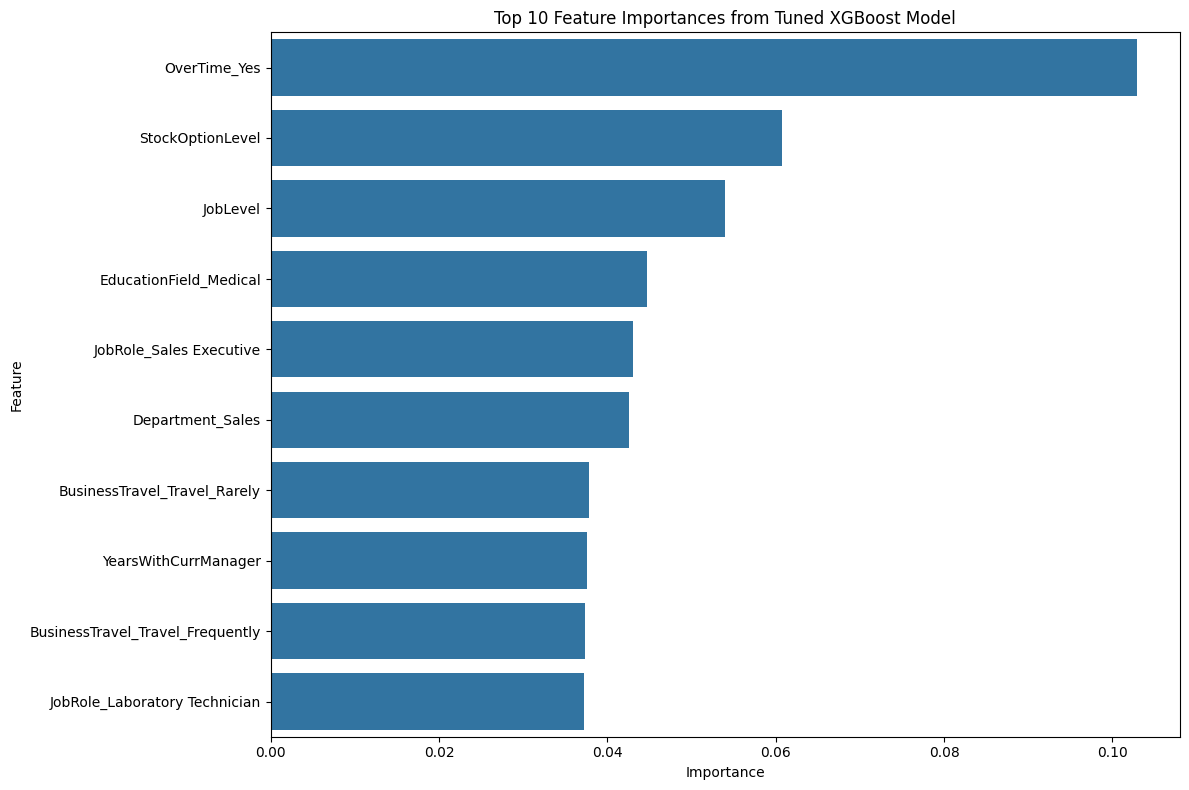

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the best XGBoost model
feature_importances = best_xgb_model.feature_importances_

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot top 10 feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title('Top 10 Feature Importances from Tuned XGBoost Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Deep Learning Model for Attrition Prediction

In [24]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the input shape based on our preprocessed features
input_shape = (X_train_resampled.shape[1],)

# Build the Sequential Keras model
model = keras.Sequential([
    keras.Input(shape=input_shape),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Add dropout for regularization
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Sigmoid for binary classification
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,129 (63.00 KB)

 Trainable params: 16,129 (63.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Deep Learning Model

In [25]:
# Train the model
history = model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=50, # You can adjust the number of epochs
    batch_size=32,
    validation_split=0.2, # Use a validation split from the training data
    verbose=1
)

print("\nModel training complete.")

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - accuracy: 0.6817 - loss: 0.6074 - precision: 0.6353 - recall: 0.3536 - val_accuracy: 0.6937 - val_loss: 0.6673 - val_precision: 1.0000 - val_recall: 0.6937
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7926 - loss: 0.4714 - precision: 0.7661 - recall: 0.6430 - val_accuracy: 0.7696 - val_loss: 0.5440 - val_precision: 1.0000 - val_recall: 0.7696
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8301 - loss: 0.3976 - precision: 0.7942 - recall: 0.7377 - val_accuracy: 0.8633 - val_loss: 0.3257 - val_precision: 1.0000 - val_recall: 0.8633
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8478 - loss: 0.3443 - precision: 0.8220 - recall: 0.7580 - val_accuracy: 0.8886 - val_loss: 0.2654 - val_precision: 1.0000 - val_recall: 0.8886
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8802 - loss: 0.3165 - precision: 0.8750 - recall: 0.7936 - val_accuracy: 0.9215 - val_loss: 0.1719 - va

### Evaluate the Deep Learning Model

In [26]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Evaluate the model on the test set
loss, accuracy, precision, recall = model.evaluate(X_test, y_test, verbose=0)

print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")

# Get predictions (probabilities) on the test set
y_pred_proba_dl = model.predict(X_test)

# Convert probabilities to binary predictions using a threshold (e.g., 0.5)
y_pred_dl = (y_pred_proba_dl > 0.5).astype(int)

print("\n### Deep Learning Model Performance ###")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dl))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dl))


Test Loss: 0.9889
Test Accuracy: 0.8435
Test Precision: 0.5185
Test Recall: 0.2979
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step

### Deep Learning Model Performance ###

Confusion Matrix:
 [[234  13]
 [ 33  14]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.52      0.30      0.38        47

    accuracy                           0.84       294
   macro avg       0.70      0.62      0.64       294
weighted avg       0.82      0.84      0.83       294



### Classification Threshold Optimization for Tuned Logistic Regression

In [27]:
from sklearn.metrics import f1_score
import numpy as np

# Get probabilities from the tuned Logistic Regression model on the test set
y_pred_proba_lr_tuned = best_lr_model.predict_proba(X_test)[:, 1] # Probability of attrition (class 1)

# Define a range of thresholds to check
thresholds = np.arange(0.1, 0.9, 0.05)

best_f1 = 0
best_threshold = 0.5 # Default threshold

# Iterate through thresholds and find the one that maximizes F1-score for the minority class
for threshold in thresholds:
    y_pred_tuned_threshold = (y_pred_proba_lr_tuned >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_tuned_threshold, pos_label=1) # Calculate F1 for minority class
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Optimal Threshold for Tuned Logistic Regression: {best_threshold:.2f}")
print(f"Best F1-score at optimal threshold: {best_f1:.2f}")

# Apply the optimal threshold to get final predictions
y_pred_lr_optimal_threshold = (y_pred_proba_lr_tuned >= best_threshold).astype(int)

# Evaluate the model with the optimal threshold
print("\n### Tuned Logistic Regression Model Performance (Optimal Threshold) ###")
print("\nAccuracy:", accuracy_score(y_test, y_pred_lr_optimal_threshold))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr_optimal_threshold))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr_optimal_threshold))

Optimal Threshold for Tuned Logistic Regression: 0.50
Best F1-score at optimal threshold: 0.54

### Tuned Logistic Regression Model Performance (Optimal Threshold) ###

Accuracy: 0.8537414965986394

Confusion Matrix:
 [[226  21]
 [ 22  25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91       247
           1       0.54      0.53      0.54        47

    accuracy                           0.85       294
   macro avg       0.73      0.72      0.73       294
weighted avg       0.85      0.85      0.85       294



## Stacking Ensemble with Logistic Regression and XGBoost

In [28]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Define base models (tuned models from previous steps)
# Ensure best_lr_model and best_xgb_model are available from previous executions
estimators = [
    ('lr', best_lr_model),
    ('xgb', best_xgb_model)
]

# Define the meta-classifier
# Using class_weight='balanced' for the meta-classifier as well
meta_classifier = LogisticRegression(solver='liblinear', random_state=42, class_weight='balanced', max_iter=1000)

# Create the StackingClassifier
# n_jobs=-1 for parallel processing during cross-validation fitting
stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=meta_classifier,
    cv=3, # Number of cross-validation folds for base models
    n_jobs=-1,
    verbose=1
)

# Train the stacking model on the resampled training data
print("\nTraining Stacking Classifier...")
stacking_model.fit(X_train_resampled, y_train_resampled)
print("Stacking Classifier training complete.")

# Make predictions on the test set
y_pred_stacked = stacking_model.predict(X_test)

# Evaluate the stacking model
print("\n### Stacking Ensemble Model Performance ###")
print("\nAccuracy:", accuracy_score(y_test, y_pred_stacked))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_stacked))
print("\nClassification Report:\n", classification_report(y_test, y_pred_stacked))


Training Stacking Classifier...
Stacking Classifier training complete.

### Stacking Ensemble Model Performance ###

Accuracy: 0.8639455782312925

Confusion Matrix:
 [[234  13]
 [ 27  20]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.95      0.92       247
           1       0.61      0.43      0.50        47

    accuracy                           0.86       294
   macro avg       0.75      0.69      0.71       294
weighted avg       0.85      0.86      0.85       294



This stacking ensemble combines the predictions of the tuned Logistic Regression and XGBoost models, which are then used as input for a final Logistic Regression meta-classifier. The evaluation metrics above show its performance on the test set. We can compare this with the individual model performances to see if the ensemble provides any benefits.

## Combined Model Performance Comparison (F1-Score and Recall)

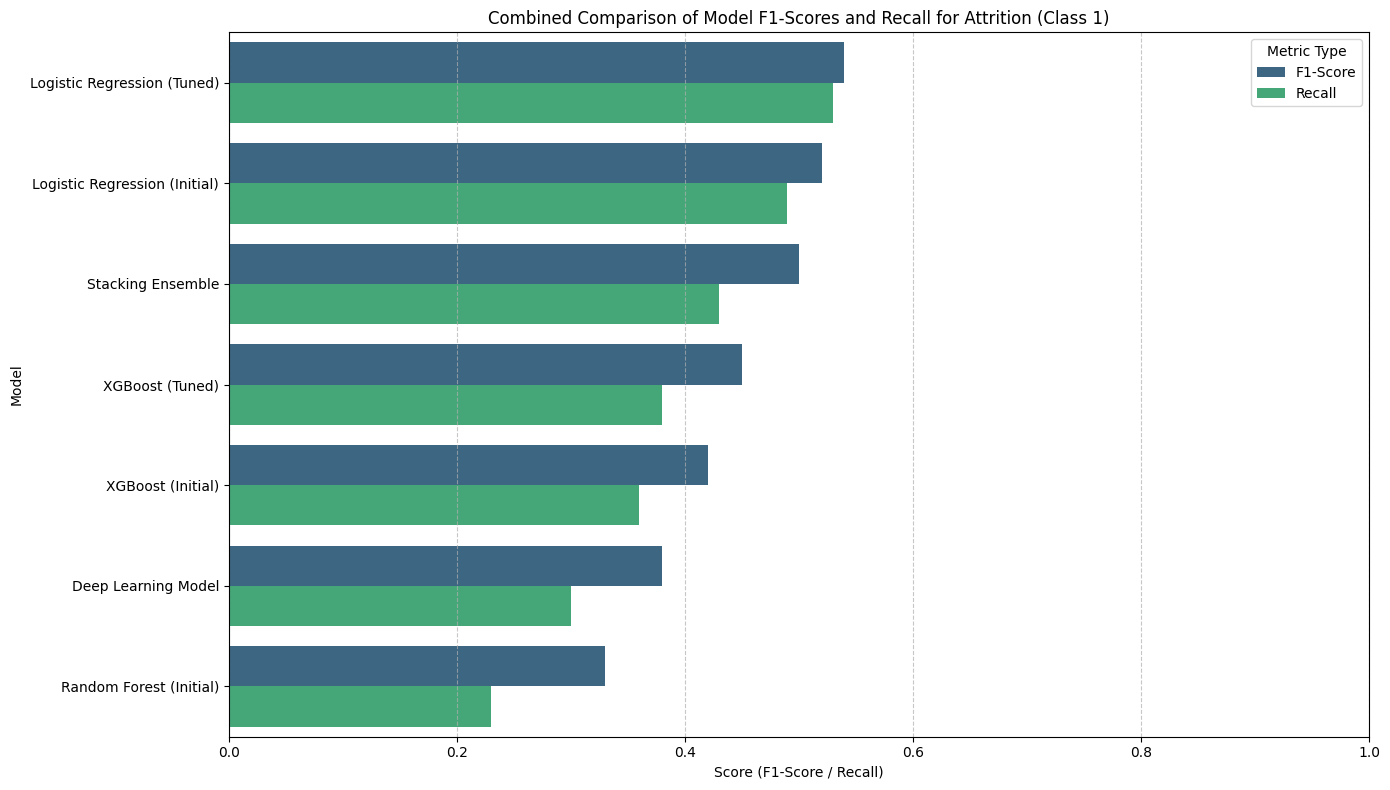

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Re-using the previously defined F1-scores and Recall scores
model_f1_scores = {
    'Logistic Regression (Initial)': 0.52,
    'Random Forest (Initial)': 0.33,
    'XGBoost (Initial)': 0.42,
    'XGBoost (Tuned)': 0.45,
    'Logistic Regression (Tuned)': 0.54,
    'Deep Learning Model': 0.38,
    'Stacking Ensemble': 0.50
}

model_recall_scores = {
    'Logistic Regression (Initial)': 0.49,
    'Random Forest (Initial)': 0.23,
    'XGBoost (Initial)': 0.36,
    'XGBoost (Tuned)': 0.38,
    'Logistic Regression (Tuned)': 0.53,
    'Deep Learning Model': 0.30,
    'Stacking Ensemble': 0.43
}

# Convert dictionaries to DataFrames
f1_df = pd.DataFrame(model_f1_scores.items(), columns=['Model', 'Score'])
f1_df['Metric'] = 'F1-Score'

recall_df = pd.DataFrame(model_recall_scores.items(), columns=['Model', 'Score'])
recall_df['Metric'] = 'Recall'

# Combine the two DataFrames
combined_df = pd.concat([f1_df, recall_df])

# Sort models by F1-Score for consistent ordering in the plot
sorted_models = f1_df.sort_values(by='Score', ascending=False)['Model'].tolist()
combined_df['Model'] = pd.Categorical(combined_df['Model'], categories=sorted_models, ordered=True)
combined_df = combined_df.sort_values(by='Model', ascending=False) # Reverse for plotting top F1 at top

# Plot the combined scores
plt.figure(figsize=(14, 8))
sns.barplot(x='Score', y='Model', hue='Metric', data=combined_df, palette='viridis')
plt.title('Combined Comparison of Model F1-Scores and Recall for Attrition (Class 1)')
plt.xlabel('Score (F1-Score / Recall)')
plt.ylabel('Model')
plt.xlim(0, 1) # Scores range from 0 to 1
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.legend(title='Metric Type')
plt.tight_layout()
plt.show()

## Saving the Best Model

In [33]:
import joblib

# Define the filename for your model
model_filename = 'tuned_logistic_regression_model.pkl'

# Save the best Logistic Regression model to a .pkl file
joblib.dump(best_lr_model, model_filename)

print(f"Best model saved to {model_filename}")

Best model saved to tuned_logistic_regression_model.pkl


You can then load this model back into your environment later using `loaded_model = joblib.load(model_filename)`.

This deep learning model provides another perspective on the attrition prediction task. The metrics above will help us understand its performance compared to the traditional machine learning models we've already built.

This output provides the performance metrics for the hyperparameter-tuned XGBoost Classifier, which was specifically optimized to maximize recall for the minority class. Compare these results with the previous models to see how tuning impacted the performance, especially for identifying employees who attrite.